This is the general code we wrote to address the remaining cases of Carlitz-extensiveness. All three methods for finding primitive τ-generators are included. <br>
During execution, progress is printed only for every 30,000th cyclotomic coset.

In [4]:
from sage.all import *
import random as py_random

# ============================================================
# Field construction
# ============================================================

def make_extension_field(q, n, gen_name='a'):
    """
    Construct F_{q^n} as an extension of F_q of degree n.
    Returns (F_q, F_q_n) as genuine FiniteField objects with
    F_q installed as a subfield of F_q_n, so that coercion and
    F_q_n.vector_space(F_q, ...) both work.
    """
    from sage.arith.misc import is_prime_power
    p, k = is_prime_power(q, get_data=True)
    if k == 0:
        raise ValueError(f"q = {q} is not a prime power")

    F_q_n = GF(p**(k * n), gen_name)
    if k == 1:
        F_q = F_q_n.prime_subfield()
    else:
        F_q = F_q_n.subfield(k, 'b')

    assert F_q_n.has_coerce_map_from(F_q)
    return F_q, F_q_n


# ============================================================
# q-cyclotomic cosets mod N = q^n - 1
# ============================================================

def nonzero_q_cyclotomic_coset_data(F_q_n, q):
    """
    Yield one record for each q-cyclotomic coset in F_q_n^*.

    If g is a multiplicative generator of F_q_n^* and N = |F_q_n^*|, then the
    nonzero element z = g^e has Frobenius orbit
        z, z^q, z^(q^2), ...
    corresponding exactly to the q-cyclotomic coset of e mod N.

    Yields dictionaries with keys:
        'rep_exp'   : representative exponent e
        'coset_exp' : full exponent coset
        'z0'        : g^e
        'orbit_z'   : [z0, z0^q, z0^(q^2), ...]
    """
    g = F_q_n.multiplicative_generator()
    N = ZZ(F_q_n.order() - 1)

    seen = bytearray(int(N))

    for e in range(int(N)):
        if seen[e]:
            continue

        x = e
        z0 = g**e
        w = z0
    
        coset = []
        orbit_z = []

        while not seen[x]:
            seen[x] = 1

            coset.append(ZZ(x))
            orbit_z.append(w)

            x = (x * q) % N
            w = w**q
            

        yield {
            'rep_exp': ZZ(e),
            'coset_exp': coset,
            'z0': z0,
            'orbit_z': orbit_z,
        }


# ============================================================
# Minimal polynomial over F_q from Frobenius orbit
# ============================================================

def minpoly_from_q_frobenius_orbit(orbit_z, F_q, var='t'):
    """
    Given the q-Frobenius orbit [z, z^q, z^(q^2), ...], return the minimal
    polynomial of z over F_q.

    Output:
        f_z in F_q[var]
    """
    F_q_polynomials = PolynomialRing(F_q, var)

    F_q_n = orbit_z[0].parent()
    F_q_n_polynomials = PolynomialRing(F_q_n, 'U')
    U = F_q_n_polynomials.gen()

    f_over_extension = prod(U - w for w in orbit_z)
    f_z = F_q_polynomials([F_q(c) for c in f_over_extension.list()])
    return f_z


# ============================================================
# Primitive projective-point candidates in P(F_q_n)
# ============================================================

def primitive_point_pair_iter(F_q, F_q_n, to_V):
    """
    Iterate over primitive projective F_q-points of F_q_n.

    For each such point, yield the canonical exponent (the unique
    representative in {1, ..., Q-1}), the corresponding field element
    g^k, and its image as a vector in (F_q)^n.

    Let N = q^n - 1 and Q = (q^n - 1)/(q - 1), and let g be a
    multiplicative generator of F_q_n^*.

    From the theory:
      - Any projective point [g^k] has a unique representative g^l
        with 0 <= l <= Q-1.
      - The point [g^k] is primitive iff gcd(k, Q) = 1.
      - [g^0] = [1] corresponds to F_q^* itself, which is not primitive
        and is therefore skipped.

    Yields triples:
        (point_exp, x_rep, v_rep)
    where:
        point_exp is k in {1, ..., Q-1} with gcd(k, Q) = 1,
        x_rep     = g^k is the representative of that primitive point,
        v_rep     = to_V(x_rep) is the corresponding vector in (F_q)^n.
    """
    g = F_q_n.multiplicative_generator()
    N = ZZ(F_q_n.order() - 1)
    q = F_q.order()
    Q = N // (q - 1)

    x = g  # x = g^1
    for k in range(1, int(Q)):
        if gcd(k, Q) == 1:
            yield (ZZ(k), x, to_V(x))
        x *= g


def primitive_point_pair_list(F_q, F_q_n, to_V):
    """
    Materialize primitive-point representatives once.
    """
    return list(primitive_point_pair_iter(F_q, F_q_n, to_V))


def primitive_multiple_on_same_point(F_q, F_q_n, point_exp, x_rep):
    """
    Given a representative x_rep = g^k of a primitive F_q-point, find a scalar
    multiple lambda*x_rep that is actually primitive in F_q_n^*.

    We search among:
        x_rep, h*x_rep, h^2*x_rep, ..., h^(q-2)*x_rep
    where h = g^Q generates F_q^* and Q = (q^n - 1)/(q - 1).

    Returns:
        primitive_x, primitive_exp
    """
    g = F_q_n.multiplicative_generator()
    N = ZZ(F_q_n.order() - 1)
    q = F_q.order()
    Q = N // (q - 1)
    h = g**Q  # generator of F_q^*

    y = x_rep
    a = ZZ(point_exp) % N

    for _ in range(q - 1):
        if gcd(a, N) == 1:
            return y, a
        y *= h
        a = (a + Q) % N

    raise RuntimeError(
        "No primitive scalar multiple found on a primitive point; this should not happen."
    )


# ============================================================
# Linear algebra over F_q
# ============================================================

def prepare_linear_algebra(F_q, F_q_n):
    """
    Prepare F_q_n as an F_q-vector space, together with conversion maps.

    Returns:
        V            : F_q-vector space
        from_V       : V -> F_q_n
        to_V         : F_q_n -> V
        basis_F_q_n  : basis of F_q_n over F_q, as field elements
        zero_v       : zero vector in V
    """
    V, from_V, to_V = F_q_n.free_module(base=F_q, map=True)
    basis_F_q_n = [from_V(v) for v in V.basis()]
    zero_v = V.zero()
    return V, from_V, to_V, basis_F_q_n, zero_v


def gamma_matrix_row_action(z, q, F_q, basis_F_q_n, to_V):
    """
    Matrix A over F_q for gamma_z(y) = z*y + y^q, in row-action convention:
        to_V(x) * A = to_V(gamma_z(x)).
    """
    rows = [to_V(z * b + b**q) for b in basis_F_q_n]
    return Matrix(F_q, rows)


def matrix_poly_eval_row_action(A, g_poly):
    """
    Evaluate polynomial g_poly at matrix A using Horner's rule.
    Row-action convention.
    """
    F_q = A.base_ring()
    n = A.nrows()
    I = identity_matrix(F_q, n)
    H = zero_matrix(F_q, n)

    for a in reversed(g_poly.list()):
        H = H * A
        if a != 0:
            H += F_q(a) * I

    return H


# ============================================================
# Factor data for m_{gamma_z}
# ============================================================

def m_gamma_factor_data(f_z, n, p, F_q_polynomials):
    """
    Compute factor data (polynomial itself, factorization & distinct factors and quotient_polynomials, i.e. m_gamma / factor_i) for
        m_gamma = f_z^(n/d) - 1
    using the p-part shortcut:
        if n/d = p^r * s with gcd(s, p) = 1, then
            f_z^(n/d) - 1 = (f_z^s - 1)^(p^r), where p is the characteristic of the field.
            It is then simpler to factorize f_z^s - 1 and adjust the multiplicities of the factors of m_gamma by multiplying with p^r.

    Theory:
    From Hsu and Nan (2011), it is known that the minimal polynomial of gamma_z is m_{gamma_z} = f_z^(n/deg(f_z)) - 1, 
    where f_z is the minimal polynomial of z over F_q.

    Returns:
        m_gamma        : full polynomial in F_q[t]
        reduced_fac    : factorization of f_z^s - 1
        full_fac       : factorization of m_gamma
        quotient_polys : [m_gamma / p_i] for distinct irreducible p_i
        distinct_facs  : [p_1, ..., p_l]
    """
    d = f_z.degree()
    e = ZZ(n // d)

    r = e.valuation(p)
    s = e // (p**r)

    reduced = f_z**s - F_q_polynomials(1)
    reduced_fac = list(reduced.factor())

    full_fac = [(pi, ai * (p**r)) for (pi, ai) in reduced_fac]

    m_gamma = F_q_polynomials(1)
    for pi, ei in full_fac:
        m_gamma *= pi**ei

    distinct_facs = [pi for (pi, _) in full_fac]
    quotient_polys = [m_gamma.quo_rem(pi)[0] for pi in distinct_facs]

    return m_gamma, reduced_fac, full_fac, quotient_polys, distinct_facs


# ============================================================
# Tau-generator testing strategies
# ============================================================

def precompute_tau_generator_test_data(
    z,
    orbit_z,
    F_q,
    n,
    lin_alg_data,
):
    """
    Precompute all fixed data needed to test whether x is a tau-generator for
    tau = gamma_z.

    Returns a dictionary containing:
        f_z, d, m_gamma, factorizations, quotient_polys, A, H_mats
    """
    q = F_q.order()
    p = F_q.characteristic()
    F_q_polynomials = PolynomialRing(F_q, 't')

    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    f_z = minpoly_from_q_frobenius_orbit(orbit_z, F_q, var='t')
    d = len(orbit_z)

    m_gamma, reduced_fac, full_fac, quotient_polys, distinct_facs = \
        m_gamma_factor_data(f_z, n, p, F_q_polynomials)

    A = gamma_matrix_row_action(z, q, F_q, basis_F_q_n, to_V)
    H_mats = [matrix_poly_eval_row_action(A, g_poly) for g_poly in quotient_polys]

    return {
        'z': z,
        'orbit_z': orbit_z,
        'f_z': f_z,
        'd': d,
        'm_gamma': m_gamma,
        'reduced_factorization': reduced_fac,
        'full_factorization': full_fac,
        'distinct_irreducible_factors': distinct_facs,
        'quotient_polys': quotient_polys,
        'A': A,
        'H_mats': H_mats,
    }

def _passes_all_evaluation_tests(vx_rep, H_mats, zero_v):
    """
    Return True iff vx_rep * H != 0 for every H in H_mats.
    """
    return all(vx_rep * H != zero_v for H in H_mats)


def tau_generator_via_evaluation_on_points(
    point_pairs,
    H_mats,
    zero_v,
    F_q,
    F_q_n,
):
    """
    Deterministic exhaustive method on primitive projective points:
    test one representative x_rep of each primitive F_q-point.

    Since tau-generatorhood is F_q-scalar invariant, if x_rep fails then every
    lambda*x_rep fails as well.

    If a point passes, convert x_rep to an actual primitive element on that
    same point.
    """
    checked_points = 0

    for point_exp, x_rep, vx_rep in point_pairs:
        checked_points += 1

        if _passes_all_evaluation_tests(vx_rep, H_mats, zero_v):
            primitive_x, primitive_exp = primitive_multiple_on_same_point(
                F_q=F_q,
                F_q_n=F_q_n,
                point_exp=point_exp,
                x_rep=x_rep,
            )
            return primitive_x, checked_points, primitive_exp

    return None, checked_points, None


def tau_generator_via_evaluation_on_points_las_vegas(
    point_pairs,
    H_mats,
    zero_v,
    F_q,
    F_q_n,
    random_trials=128,
    rng=None,
):
    """
    Las Vegas version of the evaluate method.

    Phase 1:
        test up to random_trials randomly chosen primitive projective points.

    Phase 2:
        if no witness is found, fall back to the full deterministic exhaustive scan.

    Hence this is still exact/correct overall: randomness only affects runtime,
    never correctness.
    """
    if not isinstance(point_pairs, (list, tuple)):
        point_pairs = list(point_pairs)

    if rng is None:
        rng = py_random.Random()

    total_points = len(point_pairs)
    if total_points == 0:
        return None, 0, None

    random_trials = max(0, min(int(random_trials), total_points))

    checked_points = 0
    tried_indices = set()

    # --------------------------------------------------------
    # Phase 1: randomized presearch
    # --------------------------------------------------------
    if random_trials > 0:
        random_indices = rng.sample(range(total_points), random_trials)

        for idx in random_indices:
            tried_indices.add(idx)
            point_exp, x_rep, vx_rep = point_pairs[idx]
            checked_points += 1

            if _passes_all_evaluation_tests(vx_rep, H_mats, zero_v):
                primitive_x, primitive_exp = primitive_multiple_on_same_point(
                    F_q=F_q,
                    F_q_n=F_q_n,
                    point_exp=point_exp,
                    x_rep=x_rep,
                )
                return primitive_x, checked_points, primitive_exp

    # --------------------------------------------------------
    # Phase 2: deterministic fallback
    # --------------------------------------------------------
    for idx, (point_exp, x_rep, vx_rep) in enumerate(point_pairs):
        if idx in tried_indices:
            continue

        checked_points += 1

        if _passes_all_evaluation_tests(vx_rep, H_mats, zero_v):
            primitive_x, primitive_exp = primitive_multiple_on_same_point(
                F_q=F_q,
                F_q_n=F_q_n,
                point_exp=point_exp,
                x_rep=x_rep,
            )
            return primitive_x, checked_points, primitive_exp

    return None, checked_points, None


def tau_generator_via_kernels_on_points(
    point_pairs,
    H_mats,
    F_q,
    F_q_n,
):
    """
    Kernel method on primitive projective points:
    compute v_i = ker(H_i) and test one representative per primitive point.

    In row-action convention:
        v_i = { v : v * H_i = 0 } = right_kernel(H_i^T).
    """
    kernel_spaces = [H.transpose().right_kernel() for H in H_mats]

    checked_points = 0

    for point_exp, x_rep, vx_rep in point_pairs:
        checked_points += 1

        if all(vx_rep not in W for W in kernel_spaces):
            primitive_x, primitive_exp = primitive_multiple_on_same_point(
                F_q=F_q,
                F_q_n=F_q_n,
                point_exp=point_exp,
                x_rep=x_rep,
            )
            return primitive_x, checked_points, primitive_exp, kernel_spaces

    return None, checked_points, None, kernel_spaces


# ============================================================
# Primitive tau-generator search for one fixed z
# ============================================================

def find_primitive_tau_generator_for_z(
    z,
    orbit_z,
    F_q,
    F_q_n,
    n,
    lin_alg_data,
    point_pairs,
    method="evaluate",
    return_data=False,
    randomized_evaluate=False,
    randomized_trials=128,
    rng=None,
):
    """
    For fixed z in F_q_n with q-Frobenius orbit orbit_z, let tau = gamma_z.
    Find a primitive tau-generator, if one exists.

    method:
        "evaluate"  -> test one representative per primitive F_q-point by vx*H_i != 0
        "kernel"    -> compute v_i = ker(H_i) and test one representative per primitive point

    randomized_evaluate:
        Only relevant when method == "evaluate".
        If True, first perform a randomized presearch, then fall back to the
        full deterministic scan (Las Vegas style).
    """
    if method not in {"evaluate", "kernel"}:
        raise ValueError("method must be 'evaluate' or 'kernel'")

    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    precomp = precompute_tau_generator_test_data(
        z=z,
        orbit_z=orbit_z,
        F_q=F_q,
        n=n,
        lin_alg_data=lin_alg_data,
    )

    H_mats = precomp['H_mats']

    if method == "evaluate":
        if randomized_evaluate:
            witness, checked_points, witness_exp = \
                tau_generator_via_evaluation_on_points_las_vegas(
                    point_pairs=point_pairs,
                    H_mats=H_mats,
                    zero_v=zero_v,
                    F_q=F_q,
                    F_q_n=F_q_n,
                    random_trials=randomized_trials,
                    rng=rng,
                )
        else:
            witness, checked_points, witness_exp = \
                tau_generator_via_evaluation_on_points(
                    point_pairs=point_pairs,
                    H_mats=H_mats,
                    zero_v=zero_v,
                    F_q=F_q,
                    F_q_n=F_q_n,
                )
        kernel_spaces = None

    else:
        witness, checked_points, witness_exp, kernel_spaces = \
            tau_generator_via_kernels_on_points(
                point_pairs=point_pairs,
                H_mats=H_mats,
                F_q=F_q,
                F_q_n=F_q_n,
            )

    if not return_data:
        return witness

    data = dict(precomp)
    data['primitive_points_checked'] = checked_points
    data['witness_exponent'] = witness_exp
    data['method'] = method
    data['kernel_spaces'] = kernel_spaces
    data['randomized_evaluate'] = bool(method == "evaluate" and randomized_evaluate)
    data['randomized_trials'] = int(randomized_trials) if (method == "evaluate" and randomized_evaluate) else 0

    return witness, data


# ============================================================
# Full Carlitz-extensivity test
# ============================================================

def is_carlitz_extensive_best(
    q,
    n,
    method="evaluate",
    verbose=False,
    return_data=False,
    cache_primitive_candidates=True,
    randomized_evaluate=False,
    randomized_trials=None,
    rng_seed=None,
):
    """
    Test Carlitz-extensivity of F_{q^n} / F_q.

    Main ideas:
      - treat z = 0 separately
      - treat nonzero z via q-cyclotomic cosets mod q^n - 1
      - factor only one m_{gamma_z} per Frobenius orbit / minimal polynomial
      - test one representative per primitive F_q-point
      - optionally cache the primitive-point representatives
      - transport witnesses along each orbit by x |-> x^q

    method:
      - "evaluate": usually fastest; tests vx * H_i != 0 directly
      - "kernel": computes the subspaces v_i = ker(H_i)

    randomized_evaluate:
      - only used when method == "evaluate"
      - if True, run a Las Vegas random presearch before the exhaustive scan

    randomized_trials:
      - number of random primitive projective points tested before fallback

    rng_seed:
      - optional seed for reproducible randomized runs

    Returns:
        True / False

    If return_data=True, returns:
        (True/False, F_q, F_q_n, witnesses, diagnostics)
    """
    if method not in {"evaluate", "kernel"}:
        raise ValueError("method must be 'evaluate' or 'kernel'")

    if randomized_evaluate and method != "evaluate":
        raise ValueError("randomized_evaluate is only available with method='evaluate'")

    if randomized_trials is None:
        randomized_trials=int(q**(n/2))

    F_q, F_q_n = make_extension_field(q, n)
    q0 = F_q.order()

    lin_alg_data = prepare_linear_algebra(F_q, F_q_n)
    V, from_V, to_V, basis_F_q_n, zero_v = lin_alg_data

    rng = py_random.Random(rng_seed) if randomized_evaluate else None

    point_pairs_cache = None
    if cache_primitive_candidates or randomized_evaluate:
        point_pairs_cache = primitive_point_pair_list(F_q, F_q_n, to_V)

    witnesses = {}
    diagnostics = []

    def point_pairs_source():
        if point_pairs_cache is not None:
            return point_pairs_cache
        return primitive_point_pair_iter(F_q, F_q_n, to_V)

    # --------------------------------------------------------
    # Case z = 0
    # --------------------------------------------------------
    z0 = F_q_n(0)
    orbit0 = [z0]

    primitive_x0, data0 = find_primitive_tau_generator_for_z(
        z=z0,
        orbit_z=orbit0,
        F_q=F_q,
        F_q_n=F_q_n,
        n=n,
        lin_alg_data=lin_alg_data,
        point_pairs=point_pairs_source(),
        method=method,
        return_data=True,
        randomized_evaluate=randomized_evaluate,
        randomized_trials=randomized_trials,
        rng=rng,
    )

    diagnostics.append(data0)

    if primitive_x0 is None:
        if verbose:
            print("No primitive tau-generator exists for z = 0.")
        if return_data:
            return False, F_q, F_q_n, witnesses, diagnostics
        return False

    witnesses[z0] = primitive_x0

    if verbose:
        print(
            f"z = 0, deg(f_z) = {data0['d']}, method = {method}, "
            f"primitive points checked = {data0['primitive_points_checked']}"
        )

    # --------------------------------------------------------
    # Nonzero z: one representative per q-cyclotomic coset
    # --------------------------------------------------------
    printing_index = 0
    for coset_data in nonzero_q_cyclotomic_coset_data(F_q_n, q0):
        z_rep = coset_data['z0']
        orbit_z = coset_data['orbit_z']

        primitive_x_rep, data = find_primitive_tau_generator_for_z(
            z=z_rep,
            orbit_z=orbit_z,
            F_q=F_q,
            F_q_n=F_q_n,
            n=n,
            lin_alg_data=lin_alg_data,
            point_pairs=point_pairs_source(),
            method=method,
            return_data=True,
            randomized_evaluate=randomized_evaluate,
            randomized_trials=randomized_trials,
            rng=rng,
        )

        diagnostics.append(data)

        if primitive_x_rep is None:
            if verbose:
                print(
                    f"No primitive tau-generator exists for orbit representative "
                    f"z = {z_rep}."
                )
            if return_data:
                return False, F_q, F_q_n, witnesses, diagnostics
            return False

        # Transport witness along the Frobenius orbit:
        # if z_j = z_rep^(q^j), then x_j = x_rep^(q^j) works for z_j.
        xj = primitive_x_rep
        for zj in orbit_z:
            witnesses[zj] = xj
            xj = xj**q0
            
        printing_index += 1
        if verbose and printing_index % 30000 == 0:
            print(
                f"rep exp = {coset_data['rep_exp']}, "
                f"z = {z_rep}, deg(f_z) = {data['d']}, method = {method}, "
                f"primitive points checked = {data['primitive_points_checked']}"
            )

    if return_data:
        return True, F_q, F_q_n, witnesses, diagnostics
    return True

In [5]:
from sage.all import *
import time
import csv


def benchmark_one_method(q, n, method_name, *, randomized_trials=128, rng_seed=12345,
                         cache_primitive_candidates=True, verbose=False):
    """
    Time one run of is_carlitz_extensive_best(q, n, ...).

    Returns a dictionary with fields:
        q, n, label, method, ok, seconds, randomized_evaluate, randomized_trials
    """
    kwargs = {
        'q': q,
        'n': n,
        'verbose': verbose,
        'return_data': False,
        'cache_primitive_candidates': cache_primitive_candidates,
    }

    if method_name == 'evaluate_deterministic':
        kwargs.update({
            'method': 'evaluate',
            'randomized_evaluate': False,
            'randomized_trials': 0,
            'rng_seed': None,
        })
    elif method_name == 'evaluate_las_vegas':
        kwargs.update({
            'method': 'evaluate',
            'randomized_evaluate': True,
            'randomized_trials': randomized_trials,
            'rng_seed': rng_seed,
        })
    elif method_name == 'kernel':
        kwargs.update({
            'method': 'kernel',
            'randomized_evaluate': False,
            'randomized_trials': 0,
            'rng_seed': None,
        })
    else:
        raise ValueError("Unknown method_name")

    t0 = time.perf_counter()
    ok = is_carlitz_extensive_best(**kwargs)
    t1 = time.perf_counter()

    return {
        'q': q,
        'n': n,
        'label': f"{q}^{n}",
        'method': method_name,
        'ok': bool(ok),
        'seconds': t1 - t0,
        'randomized_evaluate': bool(method_name == 'evaluate_las_vegas'),
        'randomized_trials': int(randomized_trials) if method_name == 'evaluate_las_vegas' else 0,
    }



def benchmark_case(q, n, *, randomized_trials=128, rng_seed=12345,
                   cache_primitive_candidates=True, verbose=False):
    """
    Benchmark all three methods on one case (q, n).
    """
    methods = [
        'evaluate_deterministic',
        'evaluate_las_vegas',
        'kernel',
    ]

    results = []
    for method_name in methods:
        row = benchmark_one_method(
            q, n, method_name,
            randomized_trials=randomized_trials,
            rng_seed=rng_seed,
            cache_primitive_candidates=cache_primitive_candidates,
            verbose=verbose,
        )
        results.append(row)
        print(f"[{row['label']}] {method_name:24s} ok={row['ok']!s:5s} time={row['seconds']:.6f} s")

    return results



def benchmark_suite(cases=None, *, randomized_trials=128, rng_seed=12345,
                    cache_primitive_candidates=True, verbose=False):
    """
    Benchmark the full suite.

    Default cases:
        q = 2: n = 2, 4, 6, 8, 10, 12, 14, 16
        q = 3: n = 2, 3, 4, 5, 6, 7, 8, 9
    """
    if cases is None:
        cases = [
            (2, 2), (2, 4), (2, 6), (2, 8), (2, 10), (2, 12), (2, 14), (2, 16),
            (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9)
        ]

    all_results = []
    print("=" * 72)
    print("Benchmark suite starting")
    print(f"cases = {cases}")
    print(f"randomized_trials = {randomized_trials}")
    print(f"rng_seed = {rng_seed}")
    print(f"cache_primitive_candidates = {cache_primitive_candidates}")
    print("=" * 72)

    for q, n in cases:
        print(f"\n--- Case F_{{{q}^{n}}} / F_{q} ---")
        case_results = benchmark_case(
            q, n,
            randomized_trials=randomized_trials,
            rng_seed=rng_seed,
            cache_primitive_candidates=cache_primitive_candidates,
            verbose=verbose,
        )
        all_results.extend(case_results)

    return all_results



def print_results_table(results):
    """
    Print the benchmark results as a simple text table.
    """
    print("\n" + "=" * 95)
    print(f"{'case':<8} {'method':<24} {'ok':<6} {'time (s)':>12}")
    print("-" * 95)
    for row in results:
        print(f"{row['label']:<8} {row['method']:<24} {str(row['ok']):<6} {row['seconds']:>12.6f}")
    print("=" * 95)



def save_results_csv(results, filename='benchmark_results.csv'):
    """
    Save results to a CSV file.
    """
    fieldnames = [
        'q', 'n', 'label', 'method', 'ok', 'seconds',
        'randomized_evaluate', 'randomized_trials'
    ]

    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)

    print(f"Saved CSV results to: {filename}")



def plot_results(results, filename='benchmark_plot.png', logscale=True):
    """
    Create a timing plot with one x-position per test case and one line per method.

    If logscale=True, use a logarithmic y-axis.
    """
    import matplotlib.pyplot as plt

    # preserve the original case order as it first appears
    labels = []
    seen = set()
    for row in results:
        if row['label'] not in seen:
            seen.add(row['label'])
            labels.append(row['label'])

    methods = ['evaluate_deterministic', 'evaluate_las_vegas', 'kernel']
    x = list(range(len(labels)))

    def time_for(label, method):
        for row in results:
            if row['label'] == label and row['method'] == method:
                return row['seconds']
        return float('nan')

    plt.figure(figsize=(12, 6))
    for method in methods:
        y = [time_for(label, method) for label in labels]
        plt.plot(x, y, marker='o', linewidth=2, label=method)

    plt.xticks(x, labels, rotation=45, ha='right')
    plt.xlabel(r"Field size case $q^n$")
    plt.ylabel("Runtime (seconds)")
    plt.title("Runtime comparison of Carlitz-extensivity methods")
    if logscale:
        plt.yscale('log')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"Saved plot to: {filename}")


Benchmark suite starting
cases = [(2, 2), (2, 4), (2, 6), (2, 8), (2, 10), (2, 12), (2, 14), (2, 16), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9)]
randomized_trials = 128
rng_seed = 14
cache_primitive_candidates = True

--- Case F_{2^2} / F_2 ---
[2^2] evaluate_deterministic   ok=False time=0.272341 s
[2^2] evaluate_las_vegas       ok=False time=0.002182 s
[2^2] kernel                   ok=False time=0.015995 s

--- Case F_{2^4} / F_2 ---
[2^4] evaluate_deterministic   ok=True  time=0.008051 s
[2^4] evaluate_las_vegas       ok=True  time=0.004961 s
[2^4] kernel                   ok=True  time=0.014933 s

--- Case F_{2^6} / F_2 ---
[2^6] evaluate_deterministic   ok=True  time=0.019536 s
[2^6] evaluate_las_vegas       ok=True  time=0.017485 s
[2^6] kernel                   ok=True  time=0.052870 s

--- Case F_{2^8} / F_2 ---
[2^8] evaluate_deterministic   ok=True  time=0.068055 s
[2^8] evaluate_las_vegas       ok=True  time=0.068634 s
[2^8] kernel                   ok=

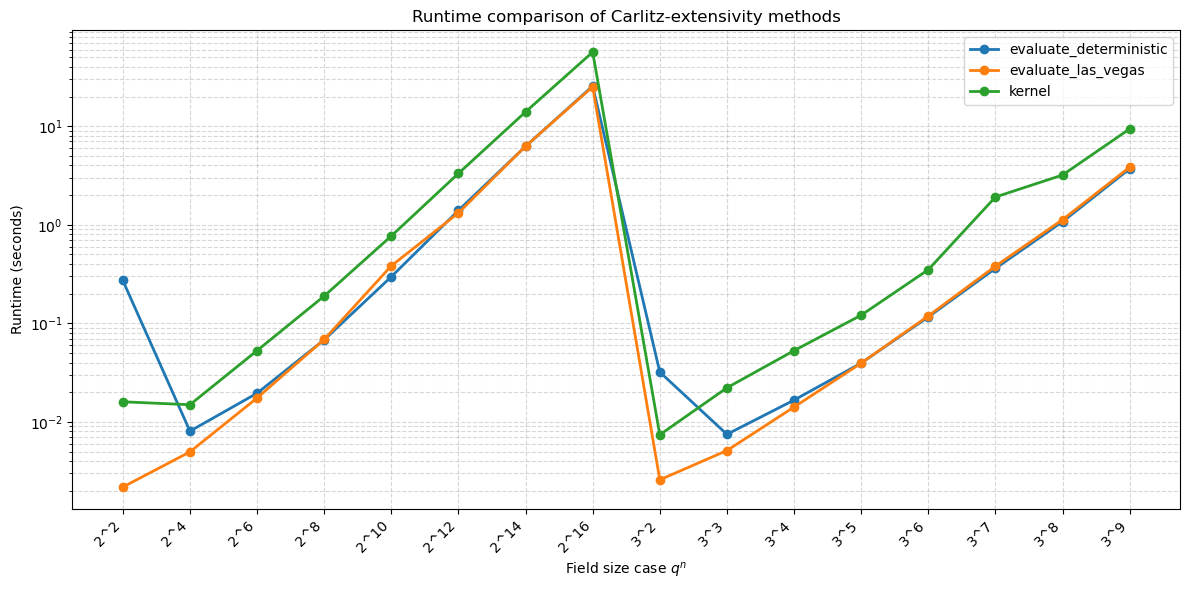

Saved plot to: benchmark_plot.png


In [6]:
results = benchmark_suite(
    randomized_trials=128,
    rng_seed=14,
    cache_primitive_candidates=True,
    verbose=False,
)

print_results_table(results)
save_results_csv(results, "benchmark_results.csv")
plot_results(results, "benchmark_plot.png", logscale=True)